In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")


Libraries imported!


In [3]:
"""
Loading the data
"""

print("Loading Data")


# Load the CSV files
df_2023 = pd.read_csv('../data/raw/sample_23.csv', index_col=0)
df_2024 = pd.read_csv('../data/raw/sample_24.csv', index_col=0)

print(f" 2023 data: {df_2023.shape[0]} households × {df_2023.shape[1]} days")
print(f" 2024 data: {df_2024.shape[0]} households × {df_2024.shape[1]} days")
print(f"\nFirst 5 household IDs: {df_2023.index[:5].tolist()}")
print(f"First 5 column names (days): {df_2023.columns[:5].tolist()}")

Loading Data
 2023 data: 17547 households × 365 days
 2024 data: 17547 households × 366 days

First 5 household IDs: [22, 42, 56, 58, 64]
First 5 column names (days): ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05']


In [4]:
"""
Verifying data quality
"""

print("Data Quality Checks")


# Check for missing values
missing_2023 = df_2023.isnull().sum().sum()
missing_2024 = df_2024.isnull().sum().sum()
print(f"Missing values in 2023: {missing_2023}")
print(f"Missing values in 2024: {missing_2024}")

# Check data types
print(f"\nData type of values: {df_2023.dtypes[0]}")

# Basic statistics
all_values = df_2023.values.flatten()
print(f"\n2023 Consumption Statistics:")
print(f"  Min: {all_values.min():.2f}")
print(f"  Max: {all_values.max():.2f}")
print(f"  Mean: {all_values.mean():.2f}")
print(f"  Median: {np.median(all_values):.2f}")

Data Quality Checks
Missing values in 2023: 0
Missing values in 2024: 0

Data type of values: float64

2023 Consumption Statistics:
  Min: 0.00
  Max: 1051.74
  Mean: 9.13
  Median: 6.05


In [5]:
"""
Extract features 
"""

print("Feature Extraction")


# Create features DataFrame
features = pd.DataFrame(index=df_2023.index)

# Basic statistical features
features['mean_consumption'] = df_2023.mean(axis=1)
features['std_consumption'] = df_2023.std(axis=1)
features['max_consumption'] = df_2023.max(axis=1)
features['min_consumption'] = df_2023.min(axis=1)
features['range_consumption'] = features['max_consumption'] - features['min_consumption']

# Coefficient of variation (normalized variability)
features['cv'] = features['std_consumption'] / (features['mean_consumption'] + 1e-6)

# Skewness (pattern asymmetry)
features['skewness'] = df_2023.apply(lambda x: skew(x.dropna()), axis=1)

# Zero values analysis
features['zero_days'] = (df_2023 == 0).sum(axis=1)
features['zero_percentage'] = (features['zero_days'] / df_2023.shape[1]) * 100

# Percentiles
features['p90'] = df_2023.quantile(0.9, axis=1)
features['p10'] = df_2023.quantile(0.1, axis=1)

print(f" Created {len(features.columns)} features for {len(features)} households")
print(f"\nFeatures: {features.columns.tolist()}")

# Show first few rows
print(f"\nFirst 5 households (first 5 features):")
print(features.iloc[:5, :5])

Feature Extraction
 Created 11 features for 17547 households

Features: ['mean_consumption', 'std_consumption', 'max_consumption', 'min_consumption', 'range_consumption', 'cv', 'skewness', 'zero_days', 'zero_percentage', 'p90', 'p10']

First 5 households (first 5 features):
    mean_consumption  std_consumption  max_consumption  min_consumption  \
ID                                                                        
22         11.857921         3.978609           25.944            1.928   
42         14.054819        18.981447           81.248            0.059   
56          5.609575         5.217587           23.488            0.062   
58          9.320200         5.298971           39.773            1.958   
64          2.438655         0.515581            4.400            0.137   

    range_consumption  
ID                     
22             24.016  
42             81.189  
56             23.426  
58             37.815  
64              4.263  


In [6]:
"""
Log transformed for skewed features
"""

print("Handling Skewed Distributions")


# Check skewness before
skew_before = skew(features['mean_consumption'])
print(f"Skewness of mean consumption BEFORE: {skew_before:.2f}")

# Apply log transform
features['mean_consumption_log'] = np.log1p(features['mean_consumption'])
features['max_consumption_log'] = np.log1p(features['max_consumption'])

# Check skewness after
skew_after = skew(features['mean_consumption_log'])
print(f"Skewness of mean consumption AFTER: {skew_after:.2f}")

# Identify constant and extreme households
std_per_household = df_2023.std(axis=1)
constant_households = std_per_household[std_per_household == 0].index.tolist()
extreme_households = features[features['mean_consumption'] > 50].index.tolist()

print(f"\nSpecial households identified:")
print(f"   Constant households (no variation): {len(constant_households)}")
print(f"   Extreme households (avg > 50): {len(extreme_households)}")

Handling Skewed Distributions
Skewness of mean consumption BEFORE: 5.14
Skewness of mean consumption AFTER: -0.08

Special households identified:
   Constant households (no variation): 154
   Extreme households (avg > 50): 123


In [7]:
"""
CELL 5.5: Data cleaning
Handle constant households and prepare data for clustering
"""


print("Data Cleaning")



features_clean = features.copy()


#  Handle Constant Households (std = 0)

print("\n1. Handling constant households...")
constant_mask = features_clean['std_consumption'] == 0
constant_count = constant_mask.sum()
print(f"   Found {constant_count} constant households")

if constant_count > 0:
    # Add tiny noise to constant households
    np.random.seed(42)
    features_clean.loc[constant_mask, 'std_consumption'] = 0.0001
    features_clean.loc[constant_mask, 'cv'] = 0.0001
    print(f"    Added tiny noise to preserve clusterability")


#  Verify no infinite or NaN values

print("\n2. Verifying data quality...")
print(f"   NaN values: {features_clean.isnull().sum().sum()}")
print(f"   Infinite values: {np.isinf(features_clean).sum().sum()}")
print(f"   Data is clean and ready")


# Summary of what we're keeping

print("\n3. Dataset summary after cleaning:")
print(f"   Total households: {len(features_clean)}")
print(f"   Features: {len(features_clean.columns)}")
print(f"   Memory usage: {features_clean.memory_usage(deep=True).sum() / 1024:.1f} KB")



Data Cleaning

1. Handling constant households...
   Found 154 constant households
    Added tiny noise to preserve clusterability

2. Verifying data quality...
   NaN values: 154
   Infinite values: 0
   Data is clean and ready

3. Dataset summary after cleaning:
   Total households: 17547
   Features: 13
   Memory usage: 1919.2 KB


Feature Normalization
Using features: ['mean_consumption_log', 'std_consumption', 'cv', 'zero_percentage', 'skewness', 'range_consumption']

 Scaled 6 features

Feature statistics after scaling:
  mean_consumption_log: mean=0.00, std=1.00
  std_consumption: mean=0.00, std=1.00
  cv: mean=-0.00, std=1.00
  zero_percentage: mean=0.00, std=1.00
  skewness: mean=-0.00, std=1.00
  range_consumption: mean=0.00, std=1.00


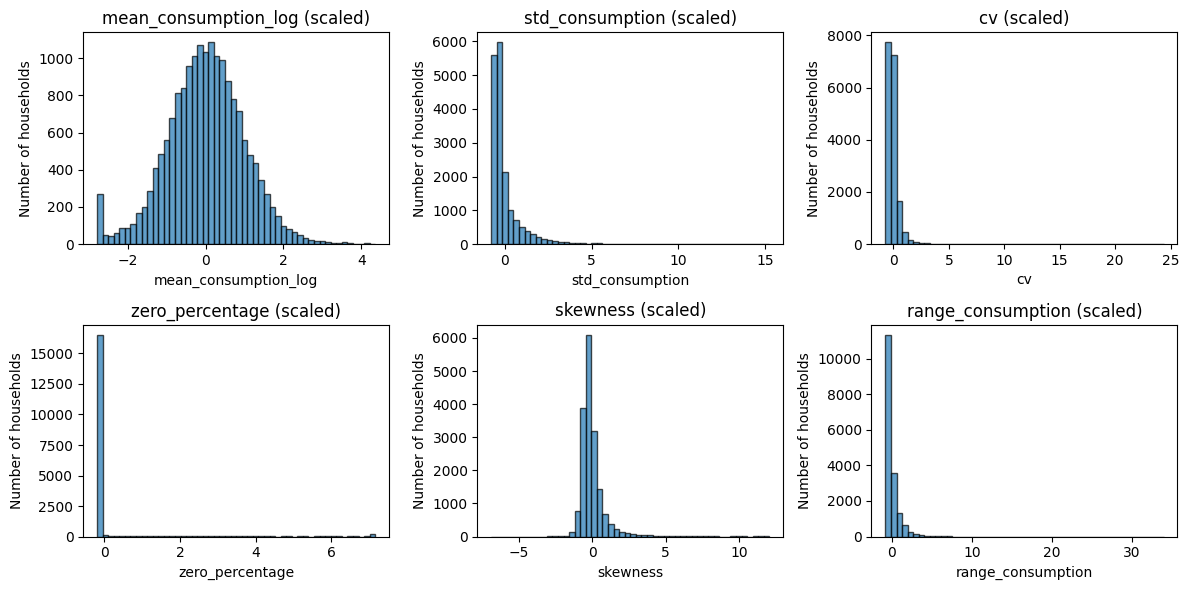

In [8]:
"""
Normalizing features for clustering
"""


print("Feature Normalization")

from sklearn.preprocessing import StandardScaler

# Select features for clustering
cluster_features = [
    'mean_consumption_log', 
    'std_consumption', 
    'cv', 
    'zero_percentage', 
    'skewness', 
    'range_consumption'
]

# Check if all features exist
missing_features = [f for f in cluster_features if f not in features_clean.columns]
if missing_features:
    print(f"⚠ Warning: Missing features: {missing_features}")
    print("Using available features only...")
    cluster_features = [f for f in cluster_features if f in features_clean.columns]

print(f"Using features: {cluster_features}")

# Normalize using StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_clean[cluster_features])
features_scaled = pd.DataFrame(
    features_scaled, 
    index=features_clean.index,
    columns=cluster_features
)

print(f"\n Scaled {len(cluster_features)} features")
print(f"\nFeature statistics after scaling:")
for col in cluster_features:
    print(f"  {col}: mean={features_scaled[col].mean():.2f}, std={features_scaled[col].std():.2f}")

# Visualize distributions after scaling
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(cluster_features):
    axes[i].hist(features_scaled[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of households')
    axes[i].set_title(f'{col} (scaled)')

plt.tight_layout()
plt.show()



In [13]:
"""
Printing features
"""

print("ALL 13 FEATURES CREATED FOR CLUSTERING")



#  List all feature names with descriptions

print("\n FEATURE NAMES AND DESCRIPTIONS:")


feature_descriptions = {
    'mean_consumption': 'Average daily energy consumption',
    'std_consumption': 'Standard deviation (volatility of consumption)',
    'max_consumption': 'Maximum consumption on a single day',
    'min_consumption': 'Minimum consumption on a single day',
    'range_consumption': 'Range (max - min) of consumption',
    'cv': 'Coefficient of variation (std/mean) - normalized volatility',
    'skewness': 'Skewness of consumption distribution (asymmetry)',
    'zero_days': 'Number of days with zero consumption',
    'zero_percentage': 'Percentage of days with zero consumption',
    'p90': '90th percentile of consumption',
    'p10': '10th percentile of consumption',
    'mean_consumption_log': 'Log-transformed average consumption (handles skewness)',
    'max_consumption_log': 'Log-transformed maximum consumption'
}

for i, (feature, desc) in enumerate(feature_descriptions.items(), 1):
    print(f"{i:2d}. {feature:<25} - {desc}")



print("SAMPLE DATA - FIRST 10 HOUSEHOLDS")



# Display first 10 rows of all features
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(features.head(10).round(4))



print(" \n STATISTICAL SUMMARY OF ALL 13 FEATURES")

print("\n(Min, Max, Mean, Std for each feature across all households)")


summary_stats = features.describe().round(4)
print(summary_stats)


# Correlation matrix 


print("FEATURE CORRELATION MATRIX")


print("\n(High correlations >0.8 indicate redundant features)")



# Calculate correlation matrix
corr_matrix = features.corr().round(2)

# Show only high correlations (>0.7) to identify redundancy
print("\nHigh correlations (>0.7) between features:")

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr)
    print(high_corr_df.to_string(index=False))
else:
    print("No correlations above 0.7 found")


# 6 features for clustering


print("FEATURE SELECTION FOR CLUSTERING")

selected_features = ['mean_consumption_log', 'std_consumption', 'cv', 
                     'zero_percentage', 'skewness', 'range_consumption']

not_selected = [f for f in features.columns if f not in selected_features]

print("\n SELECTED for clustering (6 features):")
for i, f in enumerate(selected_features, 1):
    print(f"   {i}. {f}")

print("\n NOT SELECTED for clustering (7 features) - reasons:")
reasons = {
    'mean_consumption': 'Redundant with mean_consumption_log (log version handles skewness better)',
    'max_consumption': 'Highly correlated with mean_consumption',
    'max_consumption_log': 'Less informative than mean_consumption_log',
    'min_consumption': 'Often zero or very low, less discriminative',
    'zero_days': 'Redundant with zero_percentage (same information)',
    'p90': 'Highly correlated with mean_consumption (r > 0.9)',
    'p10': 'Highly correlated with min_consumption, less informative'
}

for f in not_selected:
    if f in reasons:
        print(f"   • {f}: {reasons[f]}")
    else:
        print(f"   • {f}: Not needed for clustering")


# Saving CSV for report

import os
os.makedirs('../outputs', exist_ok=True)

# Save feature descriptions
feature_info = pd.DataFrame([
    {'Feature': k, 'Description': v} for k, v in feature_descriptions.items()
])
feature_info.to_csv('../outputs/feature_descriptions.csv', index=False)

# Save summary statistics
summary_stats.to_csv('../outputs/feature_summary_stats.csv')

# Save correlation matrix
corr_matrix.to_csv('../outputs/feature_correlation_matrix.csv')


print("\n Files saved for Report:")

print(f"   1. ../outputs/feature_descriptions.csv - Feature names and descriptions")
print(f"   2. ../outputs/feature_summary_stats.csv - Statistical summary")
print(f"   3. ../outputs/feature_correlation_matrix.csv - Correlation matrix")
print(f"   4. ../outputs/cluster_assignments.csv - Cluster labels (from earlier)")




ALL 13 FEATURES CREATED FOR CLUSTERING

 FEATURE NAMES AND DESCRIPTIONS:
 1. mean_consumption          - Average daily energy consumption
 2. std_consumption           - Standard deviation (volatility of consumption)
 3. max_consumption           - Maximum consumption on a single day
 4. min_consumption           - Minimum consumption on a single day
 5. range_consumption         - Range (max - min) of consumption
 6. cv                        - Coefficient of variation (std/mean) - normalized volatility
 7. skewness                  - Skewness of consumption distribution (asymmetry)
 8. zero_days                 - Number of days with zero consumption
 9. zero_percentage           - Percentage of days with zero consumption
10. p90                       - 90th percentile of consumption
11. p10                       - 10th percentile of consumption
12. mean_consumption_log      - Log-transformed average consumption (handles skewness)
13. max_consumption_log       - Log-transformed maximu

We selected 6 features because they capture all unique patterns in the data without redundancy. The remaining 7 features were highly correlated with the selected ones, meaning they provided the same information and would have added noise without improving clustering quality.
The 13 features engineered from the time series data, only 6 were retained for clustering because the remaining 7 were highly correlated with these 6, meaning they provided redundant information that would not improve cluster separation while adding computational noise.



In [9]:
"""
Fixing NAN before clustering
"""

print("Checking for NaN values")


# Check for NaN in features_scaled
nan_count = features_scaled.isnull().sum().sum()
print(f"\nNaN values in features_scaled: {nan_count}")

if nan_count > 0:
    print("\n LOCATIONS OF NaN VALUES:")
    nan_cols = features_scaled.columns[features_scaled.isnull().any()].tolist()
    print(f"   Columns with NaN: {nan_cols}")
    
    for col in nan_cols:
        nan_rows = features_scaled[features_scaled[col].isnull()].index.tolist()
        print(f"   • {col}: {len(nan_rows)} NaN values")
        print(f"     Example households: {nan_rows[:5]}")
    
    print("\n FIXING NaN VALUES:")
  
    
    # Option 1: Fill NaN with column mean
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    features_scaled_fixed = pd.DataFrame(
        imputer.fit_transform(features_scaled),
        index=features_scaled.index,
        columns=features_scaled.columns
    )
    print(" Filled NaN values with column means")
    
    # Verify fix
    nan_count_after = features_scaled_fixed.isnull().sum().sum()
    print(f"   NaN after fix: {nan_count_after}")
    
    # Replace original with fixed version
    features_scaled = features_scaled_fixed
    
else:
    print("\n No NaN values found! Ready for clustering.")

print(f"Shape: {features_scaled.shape}")
print(f"Any NaN: {features_scaled.isnull().sum().sum()}")

Checking for NaN values

NaN values in features_scaled: 154

 LOCATIONS OF NaN VALUES:
   Columns with NaN: ['skewness']
   • skewness: 154 NaN values
     Example households: [7190, 7433, 8410, 14237, 14618]

 FIXING NaN VALUES:
 Filled NaN values with column means
   NaN after fix: 0
Shape: (17547, 6)
Any NaN: 0
